<a href="https://colab.research.google.com/github/RodrigoLMarques/calculo-numerico-unifesp/blob/main/atividade_1/cn_atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico - Atividade prática I

## Identificação e Divisão de Tarefas

Nome: Luan Groppo Viana

RA: 177103

Realizou: A, B

Nome: Rodrigo Lopes Marques

RA: 180385

Realizou: C, Sintese e Gif

Nome: Leonardo Arantes Lopes Macedo

RA: 176558

Realizou: D

## 1. Preparação do ambiente

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import textwrap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle, FancyBboxPatch
from matplotlib.lines import Line2D
from IPython.display import Image as IPImage

def trunca(x, n):
    return math.trunc(10**n * x) / 10**n

## Parte A - truncamento e arredondamento

In [2]:
values = [3.14159265, 98.76543, 0.00498765]
names = ['x1','x2','x3']
rows=[]
for name, x in zip(names, values):
    ea_t = []
    ea_r = []
    for n in range(5):
        f = 10 ** n
        trunc = trunca(x, n)
        rnd = round(x, n)
        Ea_t = abs(x - trunc)
        Er_t = Ea_t / abs(x)
        Ep_t = 100 * Er_t

        Ea_r = abs(x - rnd)
        Er_r = Ea_r / abs(x)
        Ep_r = 100 * Er_r

        ea_t.append(Ea_t)
        ea_r.append(Ea_r)

        rows.append([name, n, 'Truncamento', trunc, Ea_t, Er_t, Ep_t])
        rows.append([name, n, 'Arredondamento', rnd, Ea_r, Er_r, Ep_r])

    plt.figure()
    plt.semilogy(range(5), ea_t, 'o-', label = 'Truncamento')
    plt.semilogy(range(5), ea_r, 's-', label = 'Arredondamento')
    plt.xlabel('n')
    plt.ylabel('Ea')
    plt.title(f'Erro absoluto - {name}')
    plt.grid(True)
    plt.legend()
    plt.savefig(f'parteA_{name}.png', dpi = 300, bbox_inches = 'tight')
    plt.close()

pd.DataFrame(rows,columns=['valor', 'n', 'metodo', 'aprox', 'Ea', 'Er', 'E%']).to_csv('parteA_tabela.csv',index = False)

### RESPOSTA PERGUNTA:
Sim, o arredondamento sempre apresenta um erro menor ou igual que o truncamento.
Isso ocorre pois o arredondamento escolhe a representação mais próxima do número
com N números significativos, enquanto o truncamento apenas descarta os
dígitos após a enesima casa decimal, sem considerar sua influência na aproximação

## Parte B - medidas de pressão arterial

In [3]:
press = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
round_i = np.rint(press)
trunc_i = np.trunc(press)

ref_mean = press.mean()

stats = []
for nome, serie in [('Original', press), ('Arredondado', round_i), ('Truncado', trunc_i)]:
    mean = np.mean(serie)
    ea = abs(mean - ref_mean)
    er = ea / ref_mean
    ep = 100 * er
    stats.append([
        nome, mean, np.min(serie), np.max(serie),
        np.max(serie) - np.min(serie),
        np.std(serie, ddof = 1), ea, er, ep
    ])

pd.DataFrame(stats, columns = ['Serie', 'Media', 'Min', 'Max', 'Amplitude', 'DP', 'Ea', 'Er', 'E%']).to_csv('parteB_estatisticas.csv', index = False)

plt.figure(figsize = (9, 4))
plt.plot(press, 'o-', label = 'Original')
plt.plot(round_i, 's-', label = 'Arred.')
plt.plot(trunc_i, '^-', label = 'Trunc.')
plt.legend()
plt.grid(True)
plt.savefig('parteB_medicoes.png', dpi = 300)
plt.close()

erro_abs = [x[6] for x in stats]
plt.figure(figsize=(7, 4))
plt.bar(["Original", "Arredondado", "Truncado"],
        erro_abs,
        color=["green", "orange", "red"])
plt.title("Erro Absoluto da Média em Relação à Série Original")
plt.xlabel("Séries")
plt.ylabel("Erro Absoluto")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('parteB_erro_absoluto.png', dpi=300, bbox_inches='tight')
plt.close()

erro_pct = [x[8] for x in stats]
plt.figure(figsize=(7, 4))
plt.bar(["Original", "Arredondado", "Truncado"],
        erro_pct,
        color=["green", "orange", "red"])
plt.title("Erro Percentual da Média em Relação à Série Original")
plt.xlabel("Séries")
plt.ylabel("Erro Percentual (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('parteB_erro_percentual.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(7, 4))
plt.hist(press, bins=6, alpha=0.6, label='Original', color='green')
plt.hist(round_i, bins=6, alpha=0.6, label='Arredondado', color='orange')
plt.title("Histograma - Dados Originais x Arredondados")
plt.xlabel("Pressão sistólica (mmHg)")
plt.ylabel("Frequência")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('parteB_histograma.png', dpi=300, bbox_inches='tight')
plt.close()


## Parte C - vazão em um tubo de pequeno diâmetro

### C.1 Precisão das variáveis

In [4]:
def Q(r_mm, mi, dp, L=0.20):
    r = r_mm * 1e-3
    return math.pi * r**4 * dp / (8 * mi * L)

r0 = 0.80 # mm
L = 0.20 # m
mi0 = 3.5e-3 # Pas
dp0 = 1200.0 # Pa

Qref = Q(r0, mi0, dp0)

casos = [
    ("todos os valores", r0, mi0, dp0),
    ("r arredondado", round(r0, 1), mi0, dp0),
    ("r truncado", trunca(r0, 1), mi0, dp0),
    ("mi arredondada", r0, round(mi0, 3), dp0),
    ("mi truncada", r0, trunca(mi0, 3), dp0),
    ("dp arredondada", r0, mi0, round(dp0, -2)),
    ("dp truncada", r0, mi0, trunca(dp0, -2)),
    ("todas arredondadas", round(r0, 1), round(mi0, 3), round(dp0, -2)),
    ("todas truncadas", trunca(r0, 1), trunca(mi0, 3), trunca(dp0, -2)),
]

print(f"Qref = {Qref:.6e} m^3/s")
for nome, r, mi, dp in casos:
    q  = Q(r, mi, dp)
    ea = abs(q - Qref)
    er = ea / abs(Qref)
    ep = er * 100
    print(f"{nome:<20} Q={q:.5e}  erro absoluto={ea:.3e}  erro relativo={er:.3e}  erro percentual={ep:.4f}%")


Qref = 2.757421e-07 m^3/s
todos os valores     Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
r arredondado        Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
r truncado           Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
mi arredondada       Q=2.41274e-07  erro absoluto=3.447e-08  erro relativo=1.250e-01  erro percentual=12.5000%
mi truncada          Q=3.21699e-07  erro absoluto=4.596e-08  erro relativo=1.667e-01  erro percentual=16.6667%
dp arredondada       Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
dp truncada          Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
todas arredondadas   Q=2.41274e-07  erro absoluto=3.447e-08  erro relativo=1.250e-01  erro percentual=12.5000%
todas truncadas      Q=3.21699e-07  erro absoluto=4.596e-08  erro relativo=1.667e-01  erro 

### C.2 Sensibilidade

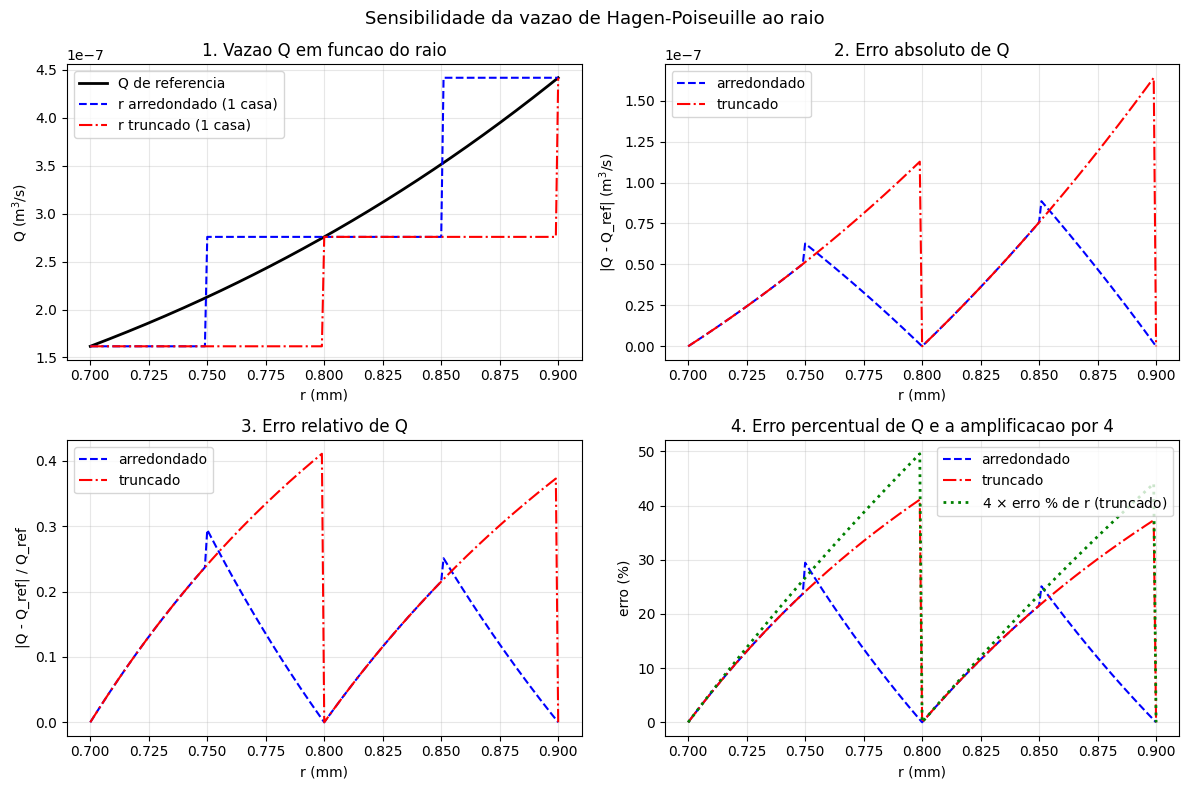

In [5]:
# C.2

r_inicial = 0.70
r_final = 0.90

# array de valores dos raios
raios       = np.round(np.linspace(r_inicial, r_final, 201), 10)
raios_arr   = np.round(raios, 1)
raios_trunc = np.trunc(raios * 10) / 10

# array dos valores de Q para cada raio
Q_ref   = Q(raios, mi0, dp0)
Q_arr   = Q(raios_arr, mi0, dp0)
Q_trunc = Q(raios_trunc, mi0, dp0)

# array dos erros absoluto, relativo e percentual
ea_arr = abs(Q_arr - Q_ref)
ea_trunc = abs(Q_trunc - Q_ref)

er_arr = ea_arr / Q_ref
er_trunc = ea_trunc / Q_ref

ep_arr = er_arr * 100
ep_trunc = er_trunc * 100

# erro percentual do proprio raio truncado
ep_r_trunc = 100 * (abs(raios_trunc - raios) / raios)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. Q em funcao de r
ax[0,0].plot(raios, Q_ref, 'k-', lw=2, label='Q de referencia')
ax[0,0].plot(raios, Q_arr, 'b--', lw=1.5, label='r arredondado (1 casa)')
ax[0,0].plot(raios, Q_trunc, 'r-.', lw=1.5, label='r truncado (1 casa)')
ax[0,0].set_xlabel('r (mm)'); ax[0,0].set_ylabel('Q (m$^3$/s)')
ax[0,0].set_title('1. Vazao Q em funcao do raio')

# 2. erro absoluto
ax[0,1].plot(raios, ea_arr, 'b--', lw=1.5, label='arredondado')
ax[0,1].plot(raios, ea_trunc, 'r-.', lw=1.5, label='truncado')
ax[0,1].set_xlabel('r (mm)'); ax[0,1].set_ylabel('|Q - Q_ref| (m$^3$/s)')
ax[0,1].set_title('2. Erro absoluto de Q')

# 3. erro relativo
ax[1,0].plot(raios, er_arr, 'b--', lw=1.5, label='arredondado')
ax[1,0].plot(raios, er_trunc, 'r-.', lw=1.5, label='truncado')
ax[1,0].set_xlabel('r (mm)'); ax[1,0].set_ylabel('|Q - Q_ref| / Q_ref')
ax[1,0].set_title('3. Erro relativo de Q')

# 4. erro percentual, comparado com 4x o erro relativo do raio
ax[1,1].plot(raios, ep_arr, 'b--', lw=1.5, label='arredondado')
ax[1,1].plot(raios, ep_trunc, 'r-.', lw=1.5, label='truncado')
ax[1,1].plot(raios, 4*ep_r_trunc, 'g:', lw=2, label=r'4 $\times$ erro % de r (truncado)')
ax[1,1].set_xlabel('r (mm)'); ax[1,1].set_ylabel('erro (%)')
ax[1,1].set_title('4. Erro percentual de Q e a amplificacao por 4')

for eixo in ax.flat:
    eixo.legend()
    eixo.grid(alpha=0.3)

fig.suptitle('Sensibilidade da vazao de Hagen-Poiseuille ao raio', fontsize=13)
fig.tight_layout()
plt.show()


#### Explicação do porque o erro no raio é amplificado na vazão
Na equação de Hagen-Poiseuille, a vazão é proporcional ao raio elevado à quarta potência, então um erro relativo no raio entra na conta quatro vezes. Se o raio erra 1%, a vazão erra cerca de 4%.

## Parte D - escoamento em um nanocateter

In [6]:
def h(r, d_p, mi, L):
  Q = (math.pi * (r** 4) * d_p)/(8*mi*L)
  return Q

def delta_1(r, delta_r, d_p, mi, L):
    Q_atual = h(r, d_p, mi, L)
    Q_novo = h(r + delta_r, d_p, mi, L)
    return (Q_novo - Q_atual) / Q_atual

def delta_2(r, delta_r):
    return ((1 + delta_r / r) ** 4) - 1

r = 50 #nm
d_p = 5000  #Pa.
mi = 0.0035 #Pa s
L = 10 #μm

Q = h(r,d_p, mi,L)

print("Qref =", Q)

Qref = 350624180088.1465


### D.1 Erro geométrico

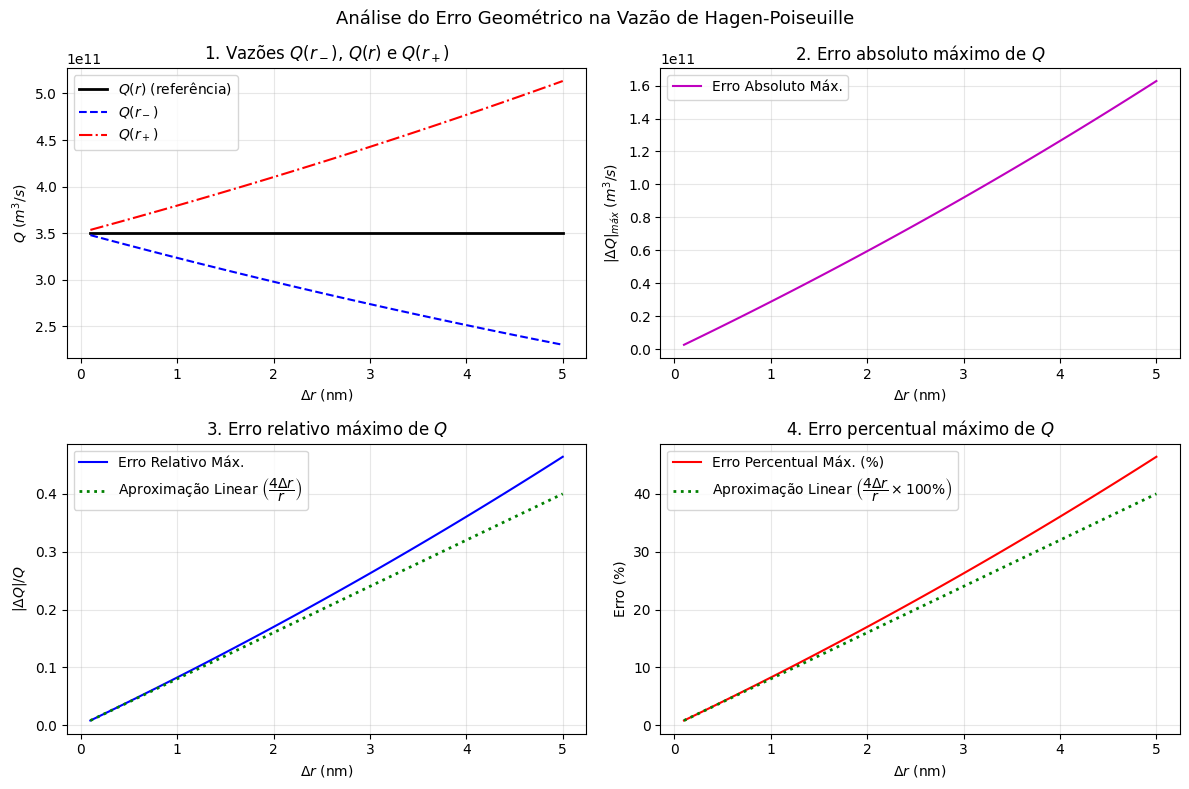

In [7]:
x = np.linspace(0.1, 5, 50, dtype=np.float64)

y0 = [] #r
y1 = [] #r-
y2 = [] #r+

maior_absoluto = []

y3 = [] #rel
y4 = [] #per

y5 = [] #aproximacao linear

for _ in x:
  y0.append(Q)

for d_r in x:
  y1.append(abs(Q - h(r-d_r,d_p, mi,L)))
  y2.append(abs(Q - h(r+d_r,d_p, mi,L)))

for i in range(50):
  maior_absoluto.append(max(y1[i],y2[i]))

for i in range(50):
  y3.append(maior_absoluto[i]/Q)

for i in range(50):
  y4.append(100*y3[i])

for d_r in x:
  y5.append((4 * d_r) / r)

# print (y5)

# Criando a figura com os 4 subplots (2x2)
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. Vazões Q(r-), Q(r) e Q(r+)
# Como y1 e y2 armazenam |Q - Q(r±)|, recriamos as curvas de vazão reais para exibição:
ax[0, 0].plot(x, y0, 'k-', lw=2, label=r'$Q(r)$ (referência)')
ax[0, 0].plot(x, [q - e for q, e in zip(y0, y1)], 'b--', lw=1.5, label=r'$Q(r_-)$')
ax[0, 0].plot(x, [q + e for q, e in zip(y0, y2)], 'r-.', lw=1.5, label=r'$Q(r_+)$')
ax[0, 0].set_xlabel(r'$\Delta r$ (nm)')
ax[0, 0].set_ylabel(r'$Q$ ($m^3/s$)')
ax[0, 0].set_title(r'1. Vazões $Q(r_-)$, $Q(r)$ e $Q(r_+)$')

# 2. Erro absoluto máximo
ax[0, 1].plot(x, maior_absoluto, 'm-', lw=1.5, label='Erro Absoluto Máx.')
ax[0, 1].set_xlabel(r'$\Delta r$ (nm)')
ax[0, 1].set_ylabel(r'$|\Delta Q|_{máx}$ ($m^3/s$)')
ax[0, 1].set_title(r'2. Erro absoluto máximo de $Q$')

# 3. Erro relativo máximo
ax[1, 0].plot(x, y3, 'b-', lw=1.5, label='Erro Relativo Máx.')
ax[1, 0].plot(x, y5, 'g:', lw=2, label=r'Aproximação Linear $\left(\dfrac{4\Delta r}{r}\right)$')
ax[1, 0].set_xlabel(r'$\Delta r$ (nm)')
ax[1, 0].set_ylabel(r'$|\Delta Q| / Q$')
ax[1, 0].set_title(r'3. Erro relativo máximo de $Q$')

# 4. Erro percentual máximo
ax[1, 1].plot(x, y4, 'r-', lw=1.5, label='Erro Percentual Máx. (%)')
ax[1, 1].plot(x, [val * 100 for val in y5], 'g:', lw=2, label=r'Aproximação Linear $\left(\dfrac{4\Delta r}{r} \times 100\%\right)$')
ax[1, 1].set_xlabel(r'$\Delta r$ (nm)')
ax[1, 1].set_ylabel('Erro (%)')
ax[1, 1].set_title(r'4. Erro percentual máximo de $Q$')

# Formatação global dos eixos
for eixo in ax.flat:
    eixo.legend()
    eixo.grid(True, alpha=0.3)

fig.suptitle('Análise do Erro Geométrico na Vazão de Hagen-Poiseuille', fontsize=13)
fig.tight_layout()

plt.show()


### D.2 Precisão computacional

np.float32
r²=  6250000.0
Q =  350624200000.0

np.float64
r²=  6250000.0
Q =  350624180088.1465

Erro absoluto: 6279.853515625
Erro relativo: 1.7910497221186953e-08

np.finfo(np.float32).eps: 1.1920929e-07
np.finfo(np.float64).eps: 2.220446049250313e-16


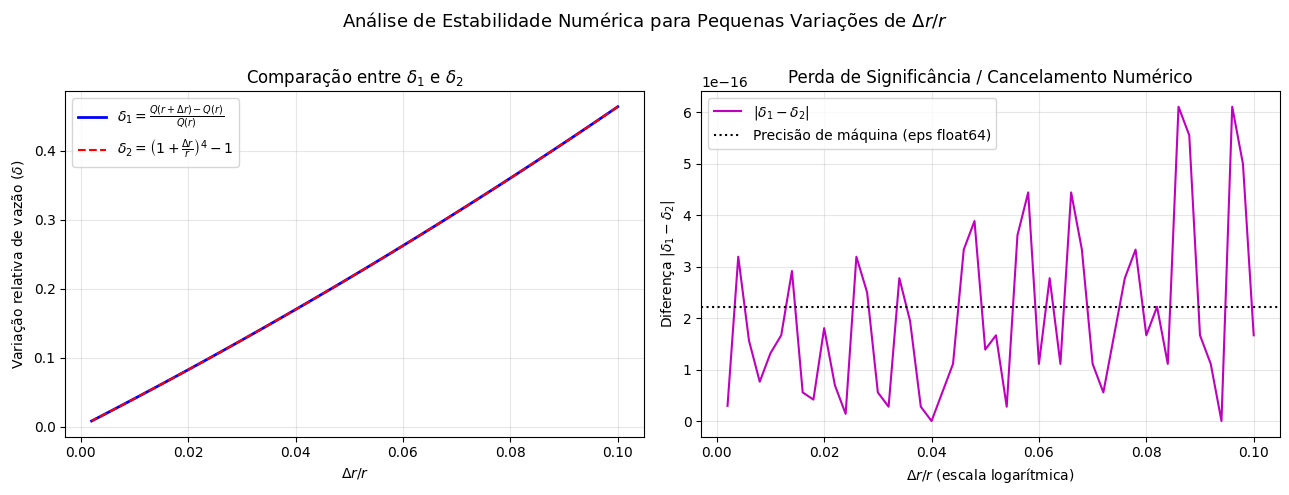

In [8]:
print("np.float32")
r1 = np.float32(50) #nm
d_p1 = np.float32(5000)  #Pa.
mi1 = np.float32(0.0035) #Pa s
L1 = np.float32(10) #μm

print("r²= ", r1**4)

Q1 = h(r1,d_p1, mi1,L1)
print("Q = ", Q1)


print("\nnp.float64")
r2 = np.float64(50) #nm
d_p2 = np.float64(5000)  #Pa.
mi2 = np.float64(0.0035) #Pa s
L2 = np.float64(10) #μm

print("r²= ", r2**4)

Q2 = h(r2,d_p2, mi2,L2)
print("Q = ", Q2)


erro_r4abs = abs(Q1 - Q2)
print("\nErro absoluto:", erro_r4abs)

erro_r4rel = erro_r4abs / abs(Q1)
print("Erro relativo:", erro_r4rel)

print("\nnp.finfo(np.float32).eps:", np.finfo(np.float32).eps)
print("np.finfo(np.float64).eps:", np.finfo(np.float64).eps)



y6 = [] #delta1
y7 = [] #delta2

d_r2 = x[::-1]

for a in d_r2:
  y6.append(delta_1(r, a, d_p, mi, L))

for a in d_r2:
  y7.append(delta_2(r, a))




# Razão Delta_r / r para o eixo X
razao_dr_r = [a / r for a in d_r2]

# Erro absoluto entre os dois métodos de cálculo
erro_cancelamento = [abs(d1 - d2) for d1, d2 in zip(y6, y7)]

# 2. Criação das figuras (2 gráficos lado a lado)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: Comparação direta entre delta_1 e delta_2
ax[0].plot(razao_dr_r, y6, 'b-', lw=2, label=r'$\delta_1 = \frac{Q(r+\Delta r) - Q(r)}{Q(r)}$')
ax[0].plot(razao_dr_r, y7, 'r--', lw=1.5, label=r'$\delta_2 = \left(1 + \frac{\Delta r}{r}\right)^4 - 1$')
ax[0].set_xlabel(r'$\Delta r / r$')
ax[0].set_ylabel(r'Variação relativa de vazão ($\delta$)')
ax[0].set_title(r'Comparação entre $\delta_1$ e $\delta_2$')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Gráfico 2: Erro por cancelamento numérico (escala logarítmica)
ax[1].plot(razao_dr_r, erro_cancelamento, 'm-', lw=1.5, label=r'$|\delta_1 - \delta_2|$')
ax[1].axhline(y=np.finfo(np.float64).eps, color='k', linestyle=':', label='Precisão de máquina (eps float64)')
# ax[1].set_xscale('log')
# ax[1].set_yscale('log')
ax[1].set_xlabel(r'$\Delta r / r$ (escala logarítmica)')
ax[1].set_ylabel(r'Diferença $|\delta_1 - \delta_2|$')
ax[1].set_title('Perda de Significância / Cancelamento Numérico')
ax[1].legend()
ax[1].grid(True, which="both", alpha=0.3)

fig.suptitle(r'Análise de Estabilidade Numérica para Pequenas Variações de $\Delta r / r$', fontsize=13)
fig.tight_layout()

plt.show()

Como as fórmulas $\delta_1$ e $\delta_2$ são algebricamente equivalentes, temos que o erro mostrado no segundo gráfico se deve a arredondamentos. Em $\delta_1$ temos uma maior quantidade de operações com variáveis float que em $\delta_2$. Assim, o erro por arredondamento é maior em $\delta_1$ e por isso há a diferença de valores que observamos.

### D.3 Fenômeno físico

Seja um nanocateter de raio $r$ e largura $L$. Temos que a razão superfície/volume é
\begin{equation*}
\dfrac{2\pi r L}{\pi r ^2 L} = \dfrac{2}{r}.
\end{equation*}
Dessa forma, observa-se que a razão superfície/volume cresce ao reduzir o valor de $r$. Isso significa que, à medida que $r$ diminui, uma fração cada vez maior do volume total do fluido passa a estar próxima da parede para sofrer influência direta dela, restando menos fluido livre no núcleo do escoamento. Consequentemente, os efeitos viscosos e de parede, que em escalas macroscópicas afetam apenas uma fina camada relativa ao volume total, passam a dominar o comportamento do escoamento como um todo. Para valores suficientemente pequenos de $r$, a fórmula de Hagen–Poiseuille passa a ser inadequada para um cálculo preciso, pois depende de hipóteses do modelo contínuo, como o não-deslizamento na parede, que deixam de valer quando efeitos moleculares na parede passam a competir com a viscosidade do fluído. Assim, para uma situação não idealizada com $r$ suficientemente pequeno, precisaríamos escolher um modelo diferente que levasse em conta os principais fatores que afetam a vazão em um nanocateter.

## Parte E - síntese visual

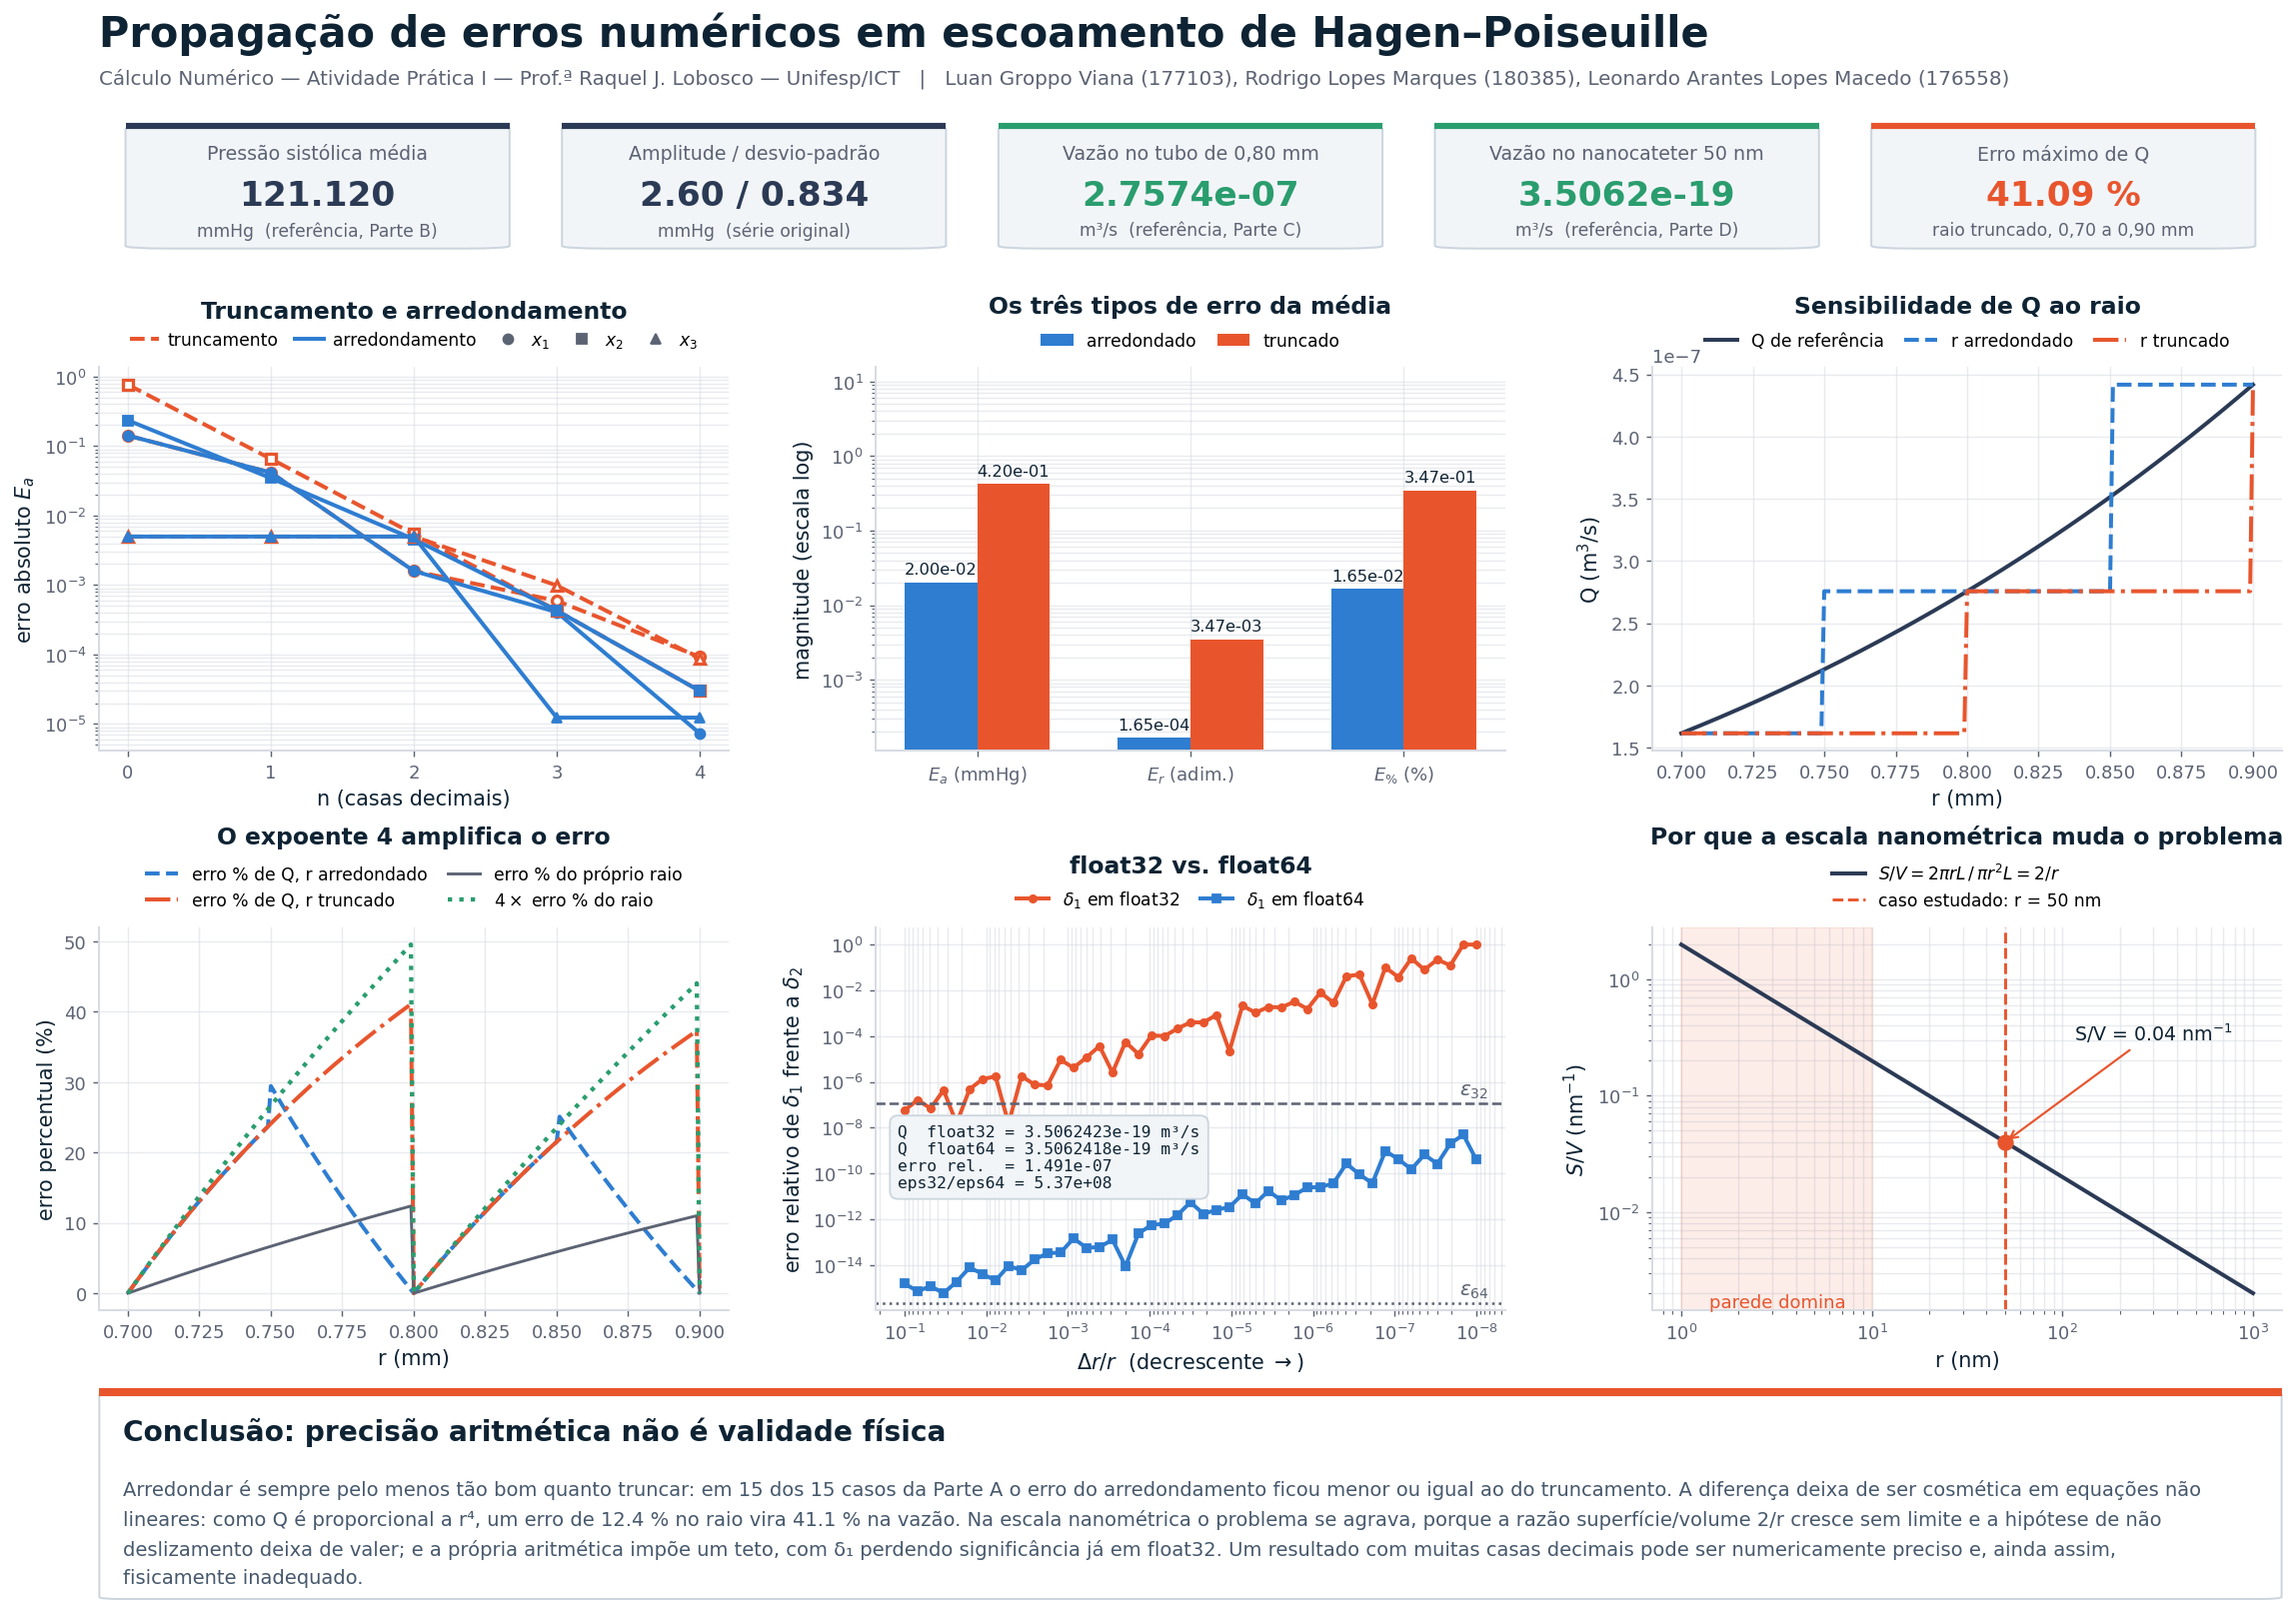

quadro_resultados.png - 2340 x 1651 px


In [14]:
DPI = 130 # 18,0 x 12,6 pol -> 2340 x 1638 px

# estilo
INK, MUTED, GRID = "#0E2333", "#5C6373", "#D7DBE3"
NAVY, ARRED, TRUNC, VERDE = "#2B3A55", "#2E7DD1", "#E8552D", "#2A9D6E"
CARD, BORDA = "#F2F5F8", "#CBD5DE"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": GRID, "axes.linewidth": 1.1, "axes.labelcolor": INK,
    "axes.labelsize": 11.5, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.titlepad": 26,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "lines.linewidth": 2.2, "lines.markersize": 5.5,
})

def titulo(ax, texto):
    ax.set_title(texto, pad=getattr(ax, "_titulo_pad", 26))

def enfeita(ax, log=False):
    """Tira as bordas de cima e da direita e liga a grade."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, which="both" if log else "major", alpha=0.55)
    ax.set_axisbelow(True)

def legenda_acima(ax, ncol=2, n_itens=None, **kw):
    """Legenda fora da área de plotagem. Afasta o título conforme o número
    de linhas que a legenda ocupa, para que os dois nunca se sobreponham."""
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005),
              ncol=ncol, columnspacing=1.2, handlelength=1.9, **kw)
    if n_itens is None:
        n_itens = len(ax.get_legend().get_texts())
    linhas = -(-n_itens // ncol)
    ax._titulo_pad = 14 + 16 * linhas

# valores de referencia
Q_NANO_SI = h(50e-9, d_p, mi, 10e-6)

# quantos dos 15 casos da Parte A tiveram erro do arredondamento <= truncamento
n_casos = sum(1 for xv in values for n in range(5)
              if abs(xv - round(xv, n)) <= abs(xv - trunca(xv, n)) + 1e-18)

#  Painéis
def painel_cartoes(ax):
    """Cartões com os principais valores de pressão e vazão."""
    ax.axis("off"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    cartoes = [
        ("Pressão sistólica média",   f"{stats[0][1]:.3f}",  "mmHg  (referência, Parte B)", NAVY),
        ("Amplitude / desvio-padrão", f"{stats[0][4]:.2f} / {stats[0][5]:.3f}", "mmHg  (série original)", NAVY),
        ("Vazão no tubo de 0,80 mm",  f"{Qref:.4e}",         "m³/s  (referência, Parte C)", VERDE),
        ("Vazão no nanocateter 50 nm", f"{Q_NANO_SI:.4e}",   "m³/s  (referência, Parte D)", VERDE),
        ("Erro máximo de Q",          f"{max(ep_trunc):.2f} %", "raio truncado, 0,70 a 0,90 mm", TRUNC),
    ]
    n = len(cartoes); larg, vao = 1 / n, 0.012
    for i, (titulo, valor, rodape, cor) in enumerate(cartoes):
        x0 = i * larg
        ax.add_patch(FancyBboxPatch(
            (x0 + vao, 0.06), larg - 2 * vao, 0.88,
            boxstyle="round,pad=0,rounding_size=0.02",
            fc=CARD, ec=BORDA, lw=1.1, transform=ax.transAxes, clip_on=False))
        ax.plot([x0 + vao, x0 + larg - vao], [0.94, 0.94], color=cor, lw=3.4,
                transform=ax.transAxes, clip_on=False, solid_capstyle="butt")
        cx = x0 + larg / 2
        ax.text(cx, 0.74, titulo, ha="center", va="center", fontsize=10.5, color=MUTED)
        ax.text(cx, 0.44, valor, ha="center", va="center", fontsize=19,
                fontweight="bold", color=cor)
        ax.text(cx, 0.19, rodape, ha="center", va="center", fontsize=9.5, color=MUTED)


def painel_trunc_vs_arred(ax):
    """1. Erro absoluto por casas decimais (Parte A).
    A cor identifica o método e o marcador identifica o valor, para que a
    relação 'arredondar <= truncar' fique visível na própria figura."""
    casas = list(range(5))
    marcas = ["o", "s", "^"]
    rotulos = [r"$x_1$", r"$x_2$", r"$x_3$"]
    for xv, m in zip(values, marcas):
        ea_t = [max(abs(xv - trunca(xv, n)), 1e-20) for n in casas]
        ea_r = [max(abs(xv - round(xv, n)), 1e-20) for n in casas]
        ax.semilogy(casas, ea_t, m + "--", color=TRUNC, mfc="white", mew=1.8)
        ax.semilogy(casas, ea_r, m + "-",  color=ARRED)
    chaves = ([Line2D([], [], color=TRUNC, ls="--", label="truncamento"),
               Line2D([], [], color=ARRED, ls="-",  label="arredondamento")] +
              [Line2D([], [], color=MUTED, ls="", marker=m, label=rt)
               for m, rt in zip(marcas, rotulos)])
    ax.set_xlabel("n (casas decimais)"); ax.set_ylabel(r"erro absoluto $E_a$")
    ax.set_xticks(casas); enfeita(ax, log=True)
    ax.legend(handles=chaves, loc="lower center", bbox_to_anchor=(0.5, 1.005),
              ncol=5, columnspacing=1.0, handlelength=1.7, handletextpad=0.5)
    ax._titulo_pad = 27
    titulo(ax, "Truncamento e arredondamento")


def painel_tres_erros(ax):
    """2. Ea, Er e E% da média das pressões (Parte B)."""
    d = {linha[0]: linha for linha in stats}
    arr, tru = d["Arredondado"], d["Truncado"]
    xs, w = np.arange(3), 0.34
    b1 = ax.bar(xs - w/2, [arr[6], arr[7], arr[8]], w, color=ARRED, label="arredondado")
    b2 = ax.bar(xs + w/2, [tru[6], tru[7], tru[8]], w, color=TRUNC, label="truncado")
    ax.set_yscale("log")
    ax.set_xticks(xs)
    ax.set_xticklabels([r"$E_a$ (mmHg)", r"$E_r$ (adim.)", r"$E_\%$ (%)"])
    ax.set_ylabel("magnitude (escala log)")
    for barras in (b1, b2):
        ax.bar_label(barras, fmt="%.2e", fontsize=9, padding=3, color=INK)
    ax.set_ylim(top=ax.get_ylim()[1] * 25)
    enfeita(ax, log=True); legenda_acima(ax)
    titulo(ax, "Os três tipos de erro da média")


def painel_sensibilidade(ax):
    """3. Vazão Q em função do raio (Parte C.2)."""
    ax.plot(raios, Q_ref,   "-",  color=NAVY,  label="Q de referência")
    ax.plot(raios, Q_arr,   "--", color=ARRED, label="r arredondado")
    ax.plot(raios, Q_trunc, "-.", color=TRUNC, label="r truncado")
    ax.set_xlabel("r (mm)"); ax.set_ylabel(r"Q (m$^3$/s)")
    enfeita(ax); legenda_acima(ax, ncol=3)
    titulo(ax, "Sensibilidade de Q ao raio")


def painel_amplificacao(ax):
    """4. O erro do raio amplificado pelo expoente quatro (Parte C.2)."""
    ax.plot(raios, ep_arr,   "--", color=ARRED, label="erro % de Q, r arredondado")
    ax.plot(raios, ep_trunc, "-.", color=TRUNC, label="erro % de Q, r truncado")
    ax.plot(raios, ep_r_trunc, "-", color=MUTED, lw=1.6, label="erro % do próprio raio")
    ax.plot(raios, 4 * np.array(ep_r_trunc), ":", color=VERDE, lw=2.4,
            label=r"$4\times$ erro % do raio")
    ax.set_xlabel("r (mm)"); ax.set_ylabel("erro percentual (%)")
    enfeita(ax); legenda_acima(ax, ncol=2)
    titulo(ax, "O expoente 4 amplifica o erro")


def painel_float(ax):
    """5. Precisão finita e perda de significância (Parte D.2).
    Varre razões Δr/r muito menores que as da célula D.2 para que o
    cancelamento apareça: δ₁ subtrai números quase iguais, δ₂ não."""
    razoes = np.logspace(-1, -8, 45)
    d2_ex = (1 + razoes) ** 4 - 1
    d1_64, d1_32 = [], []
    for t in razoes:
        q_novo = h(r * (1 + t), d_p, mi, L)
        d1_64.append((q_novo - Q) / Q)
        a, b = np.float32(q_novo), np.float32(Q)
        d1_32.append(float((a - b) / b))
    err64 = np.maximum(np.abs(np.array(d1_64) - d2_ex) / np.abs(d2_ex), 1e-18)
    err32 = np.maximum(np.abs(np.array(d1_32) - d2_ex) / np.abs(d2_ex), 1e-18)

    ax.loglog(razoes, err32, "o-", color=TRUNC, ms=4, label=r"$\delta_1$ em float32")
    ax.loglog(razoes, err64, "s-", color=ARRED, ms=4, label=r"$\delta_1$ em float64")
    for eps, estilo in ((np.finfo(np.float32).eps, "--"), (np.finfo(np.float64).eps, ":")):
        ax.axhline(eps, color=MUTED, ls=estilo, lw=1.4)
    ax.text(1.6e-8, np.finfo(np.float32).eps * 2.2, r"$\varepsilon_{32}$", color=MUTED, fontsize=11)
    ax.text(1.6e-8, np.finfo(np.float64).eps * 2.2, r"$\varepsilon_{64}$", color=MUTED, fontsize=11)
    ax.invert_xaxis()
    ax.set_xlabel(r"$\Delta r / r$  (decrescente $\rightarrow$)")
    ax.set_ylabel(r"erro relativo de $\delta_1$ frente a $\delta_2$")
    enfeita(ax, log=True); legenda_acima(ax)
    titulo(ax, "float32 vs. float64")

    q32 = h(np.float32(50e-9), np.float32(d_p), np.float32(mi), np.float32(10e-6))
    q64 = h(np.float64(50e-9), np.float64(d_p), np.float64(mi), np.float64(10e-6))
    txt = (f"Q  float32 = {float(q32):.7e} m³/s\n"
           f"Q  float64 = {float(q64):.7e} m³/s\n"
           f"erro rel.  = {abs(float(q32)-q64)/q64:.3e}\n"
           f"eps32/eps64 = {np.finfo(np.float32).eps/np.finfo(np.float64).eps:.2e}")
    ax.text(0.035, 0.40, txt, transform=ax.transAxes, va="center", ha="left",
            fontsize=9, family="monospace", color=INK,
            bbox=dict(boxstyle="round,pad=0.5", fc=CARD, ec=BORDA))


def painel_nanocateter(ax):
    """6. Razão superfície/volume e o limite do modelo contínuo (Parte D.3)."""
    raio_nm = np.logspace(0, 3, 300)
    ax.loglog(raio_nm, 2 / raio_nm, "-", color=NAVY, label=r"$S/V = 2\pi r L\,/\,\pi r^2 L = 2/r$")
    ax.axvspan(1, 10, color=TRUNC, alpha=0.10)
    ax.axvline(r, color=TRUNC, ls="--", lw=1.6, label=f"caso estudado: r = {r:.0f} nm")
    ax.plot([r], [2 / r], "o", color=TRUNC, ms=8)
    ax.annotate(f"S/V = {2/r:.2f} nm$^{{-1}}$", xy=(r, 2 / r), xytext=(115, 0.30),
                fontsize=10.5, color=INK,
                arrowprops=dict(arrowstyle="->", color=TRUNC, lw=1.2))
    ax.text(3.2, 1.5e-3, "parede domina", fontsize=10, color=TRUNC, ha="center")
    ax.set_xlabel("r (nm)"); ax.set_ylabel(r"$S/V$ (nm$^{-1}$)")
    enfeita(ax, log=True); legenda_acima(ax, ncol=1)
    titulo(ax, "Por que a escala nanométrica muda o problema")


def painel_conclusao(ax):
    """Conclusão textual do quadro."""
    ax.axis("off"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.add_patch(FancyBboxPatch(
        (0.0, 0.0), 1.0, 1.0, boxstyle="round,pad=0,rounding_size=0.010",
        fc="white", ec=BORDA, lw=1.1, transform=ax.transAxes, clip_on=False))
    ax.plot([0, 1], [1, 1], color=TRUNC, lw=4.5, transform=ax.transAxes,
            clip_on=False, solid_capstyle="butt")

    ax.text(0.011, 0.88, "Conclusão: precisão aritmética não é validade física",
            fontsize=15.5, fontweight="bold", color=INK, va="top")

    texto = (
        f"Arredondar é sempre pelo menos tão bom quanto truncar: em {n_casos} dos {n_casos} casos da Parte A o erro do arredondamento ficou menor ou igual ao do "
        f"truncamento. A diferença deixa de ser cosmética em equações não lineares: como Q é proporcional a r⁴, um erro de {max(ep_r_trunc):.1f} % no raio "
        f"vira {max(ep_trunc):.1f} % na vazão. Na escala nanométrica o problema se agrava, porque a razão superfície/volume 2/r cresce sem limite e a hipótese de não "
        f"deslizamento deixa de valer; e a própria aritmética impõe um teto, com δ₁ perdendo significância já em float32. Um resultado com muitas casas decimais "
        f"pode ser numericamente preciso e, ainda assim, fisicamente inadequado."
    )
    ax.text(0.011, 0.58, textwrap.fill(texto, 208), fontsize=10.8, color="#46586C",
            va="top", linespacing=1.62)


#  Montagem do quadro
fig = plt.figure(figsize=(18, 12.7), dpi=DPI, facecolor="white")

# Grade externa: as quatro faixas do quadro, com pouco espaço entre elas.
# As linhas de índice ímpar são espaçadores: com hspace=0 cada intervalo
# do quadro fica sob controle direto, sem depender da altura média das faixas.
externa = GridSpec(7, 1, figure=fig,
                   height_ratios=[0.40, 0.16, 0.78, 0.62, 5.30, 0.46, 1.16],
                   hspace=0.0,
                   left=0.045, right=0.978, top=0.978, bottom=0.020)

# Grade interna: apenas os seis painéis, com folga suficiente para que o
# título de cada um nunca encoste no rótulo do eixo do painel de cima.
interna = GridSpecFromSubplotSpec(2, 3, subplot_spec=externa[4],
                                  hspace=0.46, wspace=0.235)

# cabeçalho
cab = fig.add_subplot(externa[0]); cab.axis("off")
cab.text(0, 0.78, "Propagação de erros numéricos em escoamento de Hagen–Poiseuille",
         fontsize=23, fontweight="bold", color=INK, va="center")
cab.text(0, 0.16, "Cálculo Numérico — Atividade Prática I — Prof.ª Raquel J. Lobosco — Unifesp/ICT   |   "
                  "Luan Groppo Viana (177103), Rodrigo Lopes Marques (180385), Leonardo Arantes Lopes Macedo (176558)",
         fontsize=11, color=MUTED, va="center")

painel_cartoes(fig.add_subplot(externa[2]))

painel_trunc_vs_arred(fig.add_subplot(interna[0, 0]))
painel_tres_erros(fig.add_subplot(interna[0, 1]))
painel_sensibilidade(fig.add_subplot(interna[0, 2]))
painel_amplificacao(fig.add_subplot(interna[1, 0]))
painel_float(fig.add_subplot(interna[1, 1]))
painel_nanocateter(fig.add_subplot(interna[1, 2]))

painel_conclusao(fig.add_subplot(externa[6]))

fig.savefig("quadro_resultados.png", dpi=DPI, facecolor="white")
plt.show()
print("quadro_resultados.png -", int(18 * DPI), "x", int(12.7 * DPI), "px")

## Conclusão geral

Parte A: Sim, arredondar sempre gera erro menor ou igual do que truncar, pois truncar apenas o algarismo aonde o número será truncado, enquanto arredondar considera o próximo algarismo para chegar numa aproximação melhor

Parte B: A comparação entre os formatos dos dados mostra que a representação inteira simplifia mas introduz alterações nas estatísticas descritivas. Em geral, o arredondamento para o inteiro mais próximo tende a preservar a média da amostra, produzindo erros menores em relação à média de referencia, enquanto o truncamento causa uma perda maior de precisão. Para essa amostra, a representação inteira é relativamente adequada, mas não preserva com precisão a dispersão dos dados, senod necessário outra representação.

Parte C: Por conta do acûmulo de incertezas. Ao considerar um erro na medida, cujo expoente normalmente é de primeira ordem, em equações mais complexas de segunda, terceira, ou quarta ordem, eleva também o erro para o expoente em questão. Isso é visto na disparidade entre os valores de incerteza do raio e da vazão.

Parte D2: Como as fórmulas  δ1  e  δ2  são algebricamente equivalentes, temos que o erro mostrado no segundo gráfico se deve a arredondamentos. Em  δ1  temos uma maior quantidade de operações com variáveis float que em  δ2 . Assim, o erro por arredondamento é maior em  δ1  e por isso há a diferença de valores que observamos.

Parte D3: De acordo com a fórmula apresentada, a razão superfície/volume cresce ao reduzir o raio, ou seja, conforme o raio diminui maior o contato entre o fluido e a parede de forma proporcional. Dessa forma, o escoamento passa a agir de forma significativa de acordo com a diminuição de fluido livre. Para raios muito pequenos, a fórmula de Hagen–Poiseuill passa a ser inaqueda pois considera o não deslizamento na parede, que deixa de vale quando efeitos moleculares na parede compete com a viscosidade do fluido. Assim, para a situação descrita, precisaria ser escolhido outro modelo que leve em consideração os fatores mencionados que afetam a vazão do nanocateter




## GIF demonstrativo

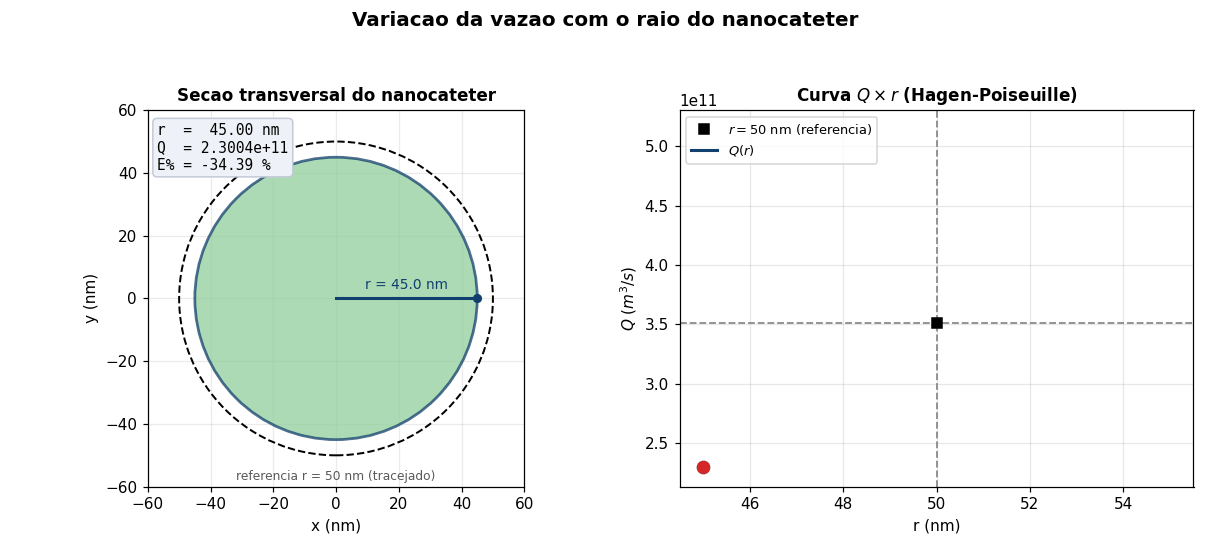

In [ ]:
N_FRAMES = 51 # 45 -> 55 nm em passos de 0.2 nm
FPS = 10      # ~5 s de duracao
raios_gif = np.linspace(45, 55, N_FRAMES)

Q_ref50 = h(50.0, d_p, mi, L)
Q_gif = np.array([h(rr, d_p, mi, L) for rr in raios_gif])
erro_pct = 100 * np.abs(Q_gif - Q_ref50) / Q_ref50

fig, (axc, axq) = plt.subplots(1, 2, figsize=(11, 5), dpi=110, facecolor="white")

# painel: secao transversal
LIM = 60
axc.set_aspect("equal")
axc.set_xlim(-LIM, LIM); axc.set_ylim(-LIM, LIM)
axc.set_xlabel("x (nm)"); axc.set_ylabel("y (nm)")
axc.set_title("Secao transversal do nanocateter", fontsize=11, fontweight="bold")
axc.grid(alpha=0.25)

axc.add_patch(Circle((0, 0), 50, fill=False, ec="k", ls="--", lw=1.3, zorder=3))
axc.text(0, -LIM + 2, "referencia r = 50 nm (tracejado)",
         ha="center", fontsize=8, color="0.35")

secao = Circle((0, 0), raios_gif[0], fc="#7fb2e5", ec="#12406e", lw=1.8, alpha=0.75, zorder=2)
axc.add_patch(secao)
linha_r, = axc.plot([0, raios_gif[0]], [0, 0], color="#12406e", lw=2, zorder=4)
ponto_r, = axc.plot([raios_gif[0]], [0], "o", color="#12406e", ms=5, zorder=5)
rot_r = axc.text(raios_gif[0] / 2, 3, "", ha="center", fontsize=9, color="#12406e", zorder=5)

caixa = axc.text(-LIM + 3, LIM - 4, "", va="top", ha="left", fontsize=9.5,
                 family="monospace",
                 bbox=dict(boxstyle="round", fc="#eef2f8", ec="#c3cad8"), zorder=6)

# painel: curva Q x r
axq.set_xlim(44.5, 55.5)
mQ = 0.06 * (Q_gif.max() - Q_gif.min())
axq.set_ylim(Q_gif.min() - mQ, Q_gif.max() + mQ)
axq.set_xlabel("r (nm)"); axq.set_ylabel(r"$Q$ ($m^3/s$)")
axq.set_title(r"Curva $Q \times r$ (Hagen-Poiseuille)", fontsize=11, fontweight="bold")
axq.grid(alpha=0.3)
axq.axvline(50, color="0.55", ls="--", lw=1.2)
axq.axhline(Q_ref50, color="0.55", ls="--", lw=1.2)
axq.plot([50], [Q_ref50], "ks", ms=6, label=r"$r = 50$ nm (referencia)")

curva, = axq.plot([], [], "-", color="#12406e", lw=2, label=r"$Q(r)$")
cabeca, = axq.plot([], [], "o", color="#d62728", ms=8, zorder=5)
axq.legend(fontsize=8.5, loc="upper left")


def atualiza(k):
    rk, Qk, Ek = raios_gif[k], Q_gif[k], erro_pct[k]
    sinal = "+" if Qk >= Q_ref50 else "-"

    secao.set_radius(rk)
    secao.set_facecolor("#f2a65a" if rk > 50 else ("#8fce9b" if rk < 50 else "#7fb2e5"))
    linha_r.set_data([0, rk], [0, 0])
    ponto_r.set_data([rk], [0])
    rot_r.set_position((rk / 2, 3))
    rot_r.set_text(f"r = {rk:.1f} nm")

    caixa.set_text(f"r  = {rk:6.2f} nm\n"
                   f"Q  = {Qk:.4e}\n"
                   f"E% = {sinal}{Ek:5.2f} %")

    curva.set_data(raios_gif[:k + 1], Q_gif[:k + 1])
    cabeca.set_data([rk], [Qk])
    return secao, linha_r, ponto_r, rot_r, caixa, curva, cabeca


fig.suptitle("Variacao da vazao com o raio do nanocateter", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])

anim = FuncAnimation(fig, atualiza, frames=N_FRAMES, interval=1000 / FPS, blit=False)
anim.save("nanocateter.gif", writer=PillowWriter(fps=FPS))
plt.close(fig) # evita a figura estatica duplicada

from IPython.display import Image as IPImage
IPImage(filename="nanocateter.gif", embed=True) # ultima linha da celula